In [2]:
# Import core Qiskit modules for building and running quantum circuits
from qiskit import *


In [8]:
# Create a quantum register containing 3 qubits
qr = QuantumRegister(3)

# Create a classical register with 1 classical bit
# (This is used to store measurement results)
cr = ClassicalRegister(3)

# Create a quantum circuit using the quantum and classical registers
circuit = QuantumCircuit(qr, cr)

# Apply a Hadamard gate to qubit 2
# The Hadamard gate creates a superposition state:
# |0⟩ → (|0⟩ + |1⟩)/√2
circuit.h(2)

# Apply a CNOT gate
# qubit 2 = control qubit
# qubit 1 = target qubit
# If qubit 2 is |1⟩, qubit 1 will be flipped
circuit.cx(2, 1)

# Apply another CNOT gate
# qubit 2 = control
# qubit 0 = target
circuit.cx(2, 0)

# Measure all qubits and store the results in classical bits
circuit.measure_all()

# Display the circuit diagram
circuit.draw()


┌───┐ ░ ┌─┐      
  q2_0: ──────────┤ X ├─░─┤M├──────
             ┌───┐└─┬─┘ ░ └╥┘┌─┐   
  q2_1: ─────┤ X ├──┼───░──╫─┤M├───
        ┌───┐└─┬─┘  │   ░  ║ └╥┘┌─┐
  q2_2: ┤ H ├──■────■───░──╫──╫─┤M├
        └───┘           ░  ║  ║ └╥┘
  c2: 3/═══════════════════╬══╬══╬═
                           ║  ║  ║ 
meas: 3/═══════════════════╩══╩══╩═
                           0  1  2

Measurement results: {'000 000': 528, '111 000': 496}


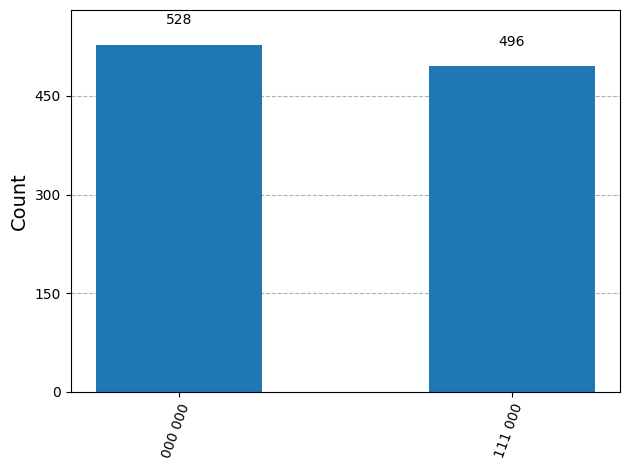

In [9]:
# Import a simple quantum simulator backend
from qiskit.providers.basic_provider import BasicProvider
from qiskit.visualization import plot_histogram

# Create the simulator backend that mimics a quantum computer
simulator = BasicProvider().get_backend('basic_simulator')

# Transpile the circuit so it is compatible with the simulator
# Transpilation converts the circuit to the simulator's supported gate set
compiled_circuit = transpile(circuit, simulator)

# Execute the circuit on the simulator
# shots=1024 means the circuit is run 1024 times
# Each run produces one measurement outcome
result = simulator.run(compiled_circuit, shots=1024).result()

# Print the raw measurement counts (how many times each result occurred)
print("Measurement results:", result.get_counts())

# Plot a histogram showing the distribution of measurement outcomes
plot_histogram(result.get_counts())

In [7]:
from qiskit.qasm2 import dumps
print(dumps(circuit))

OPENQASM 2.0;
include "qelib1.inc";
qreg q1[3];
creg c1[1];
creg meas[3];
h q1[2];
cx q1[2],q1[1];
cx q1[2],q1[0];
barrier q1[0],q1[1],q1[2];
measure q1[0] -> meas[0];
measure q1[1] -> meas[1];
measure q1[2] -> meas[2];
